In [ ]:
!pip install datasets

In [4]:
import pandas as pd
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df1 = pd.read_csv("/content/drive/MyDrive/archive/1429_1.csv")
df2 = pd.read_csv("/content/drive/MyDrive/archive/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv")
df3 = pd.read_csv("/content/drive/MyDrive/archive/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv")
data = pd.concat([df1, df2, df3], ignore_index=True)

<ipython-input-6-2e5af135c397>:1: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("/content/drive/MyDrive/archive/1429_1.csv")


In [7]:
df = data[['reviews.text', 'reviews.rating']].copy()

# Map ratings to sentiment
def map_sentiment(rating):
    if rating in [1, 2]:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['reviews.rating'].apply(map_sentiment)
df.dropna(subset=['reviews.text'], inplace=True)


In [8]:
df['sentiment'].value_counts().sort_index(ascending=False)

,count
sentiment,
positive,62579
neutral,2902
negative,2510


In [9]:
# Split into classes
df_pos = df[df.sentiment == 'positive']
df_neu = df[df.sentiment == 'neutral']
df_neg = df[df.sentiment == 'negative']

# Downsample positive class to match minority class
df_pos_down = resample(df_pos, replace=False, n_samples=4000, random_state=42)
df_balanced = pd.concat([df_pos_down, df_neu, df_neg])
df_balanced = df_balanced.sample(frac=1, random_state=42)  # Shuffle

In [10]:
df_balanced['sentiment'].value_counts().sort_index(ascending=False)

,count
sentiment,
positive,4000
neutral,2902
negative,2510


In [11]:
label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
df_balanced['label'] = df_balanced['sentiment'].map(label_map)

In [12]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df_balanced['reviews.text'], df_balanced['label'], test_size=0.2, random_state=42
)

In [13]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=256)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=256)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [14]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {k: torch.tensor(v[idx]) for k, v in self.encodings.items()} | {'labels': torch.tensor(self.labels[idx])}

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, list(train_labels))
test_dataset = SentimentDataset(test_encodings, list(test_labels))

In [15]:
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=3)

training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-15-6f2b36d80c0a>:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [16]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Evaluation Function
def evaluate_model(trainer, test_dataset, test_labels):
    preds = trainer.predict(test_dataset)
    y_pred = np.argmax(preds.predictions, axis=1)

    # Accuracy
    acc = accuracy_score(test_labels, y_pred)

    # Precision, Recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(test_labels, y_pred, average=None, labels=[0, 1, 2])

    # Label mapping
    label_names = ['positive', 'neutral', 'negative']

    # Print detailed results
    print("\nEvaluation Metrics")
    print(f"Accuracy: {acc * 100:.2f}%\n")
    print("Precision, Recall, and F1-score for each class:")
    for i, label in enumerate(label_names):
        print(f"- Class '{label}': Precision={precision[i]:.2f}, Recall={recall[i]:.2f}, F1-score={f1[i]:.2f}")

    # Confusion Matrix
    print("\n Confusion matrix (actual vs. predicted):")
    cm = confusion_matrix(test_labels, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    return y_pred

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: azamsud-745-745 (azamsud-745-745-university-of-jeddah) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss
1,No log,0.568844
2,0.637500,0.525821
3,0.419100,0.536444



Evaluation Metrics
Accuracy: 81.15%

Precision, Recall, and F1-score for each class:
- Class 'positive': Precision=0.85, Recall=0.91, F1-score=0.88
- Class 'neutral': Precision=0.71, Recall=0.72, F1-score=0.71
- Class 'negative': Precision=0.87, Recall=0.76, F1-score=0.81

 Confusion matrix (actual vs. predicted):


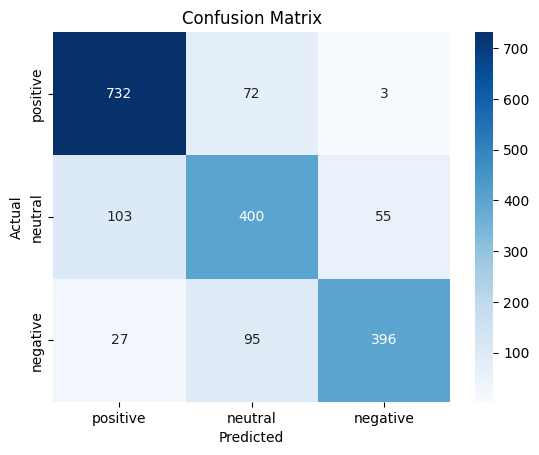

In [17]:
# Train
trainer.train()

# Evaluate
_ = evaluate_model(trainer, test_dataset, list(test_labels))

              precision    recall  f1-score   support

    positive       0.85      0.91      0.88       807
     neutral       0.71      0.72      0.71       558
    negative       0.87      0.76      0.81       518

    accuracy                           0.81      1883
   macro avg       0.81      0.80      0.80      1883
weighted avg       0.81      0.81      0.81      1883



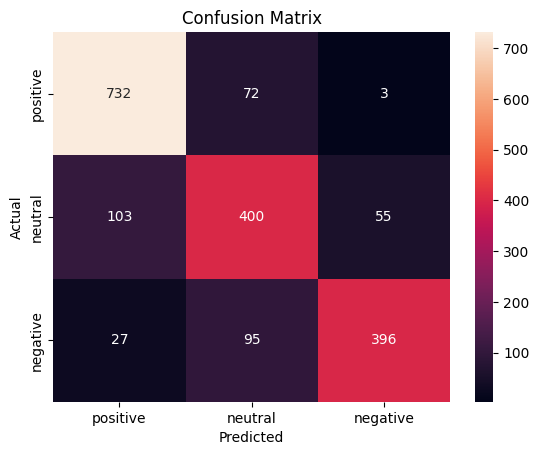

In [18]:
# Predictions
preds = trainer.predict(test_dataset)
y_pred = np.argmax(preds.predictions, axis=1)

# Report
print(classification_report(test_labels, y_pred, target_names=['positive', 'neutral', 'negative']))

# Confusion Matrix
cm = confusion_matrix(test_labels, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['positive', 'neutral', 'negative'], yticklabels=['positive', 'neutral', 'negative'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
# Save model and tokenizer
model_save_path = "./sentiment-model"
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"\n✅ Model saved to {model_save_path}")


✅ Model saved to ./sentiment-model


In [ ]:
df_balanced['reviews.rating'].value_counts().sort_index(ascending=False)

,count
reviews.rating,
5,3890
4,1110
3,1403
2,670
1,1028


In [ ]:
# Display 5 random sample reviews from df1
print(df1['reviews.text'].dropna().sample(5, random_state=42).to_string(index=False))


Awesome product! Backlit, shows you page number...
I love it, easy to learn and operate. Quick res...
This product is really helpful and excellent fo...
My husband and I purchased the new Amazon Kindl...
The screen is adequate and the service is relia...


# Using roberta model

In [20]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification

# Load tokenizer and model
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=3)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
# Tokenize
train_encodings = tokenizer(train_texts.tolist(), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts.tolist(), truncation=True, padding=True, max_length=128)

# Wrap in Dataset objects
train_dataset = SentimentDataset(train_encodings, train_labels.tolist())
test_dataset = SentimentDataset(test_encodings, test_labels.tolist())

In [22]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average=None, zero_division=0)

    print("\nEvaluation Metrics")
    print(f"Accuracy: {acc:.4f}")

    for i in range(3):
        print(f"Class {i} — Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1-score: {f1[i]:.4f}")

    print("\nClassification Report:")
    print(classification_report(labels, preds, digits=4))

    print("Confusion Matrix:")
    print(confusion_matrix(labels, preds))

    return {
        'accuracy': acc,
        'precision': precision.mean(),
        'recall': recall.mean(),
        'f1': f1.mean(),
    }

In [23]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    logging_dir='./logs',
    logging_steps=10,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-23-e387f8241f97>:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.503900,0.569016,0.777483,0.774634,0.776930,0.773773
2,0.480600,0.522376,0.818906,0.811596,0.806245,0.808463
3,0.234600,0.570314,0.833776,0.827977,0.825184,0.826504



Evaluation Metrics
Accuracy: 0.7775
Class 0 — Precision: 0.8897, Recall: 0.7893, F1-score: 0.8365
Class 1 — Precision: 0.6248, Recall: 0.7133, F1-score: 0.6661
Class 2 — Precision: 0.8094, Recall: 0.8282, F1-score: 0.8187

Classification Report:
              precision    recall  f1-score   support

           0     0.8897    0.7893    0.8365       807
           1     0.6248    0.7133    0.6661       558
           2     0.8094    0.8282    0.8187       518

    accuracy                         0.7775      1883
   macro avg     0.7746    0.7769    0.7738      1883
weighted avg     0.7891    0.7775    0.7811      1883

Confusion Matrix:
[[637 161   9]
 [ 68 398  92]
 [ 11  78 429]]

Evaluation Metrics
Accuracy: 0.8189
Class 0 — Precision: 0.8568, Recall: 0.9046, F1-score: 0.8800
Class 1 — Precision: 0.7311, Recall: 0.6918, F1-score: 0.7109
Class 2 — Precision: 0.8469, Recall: 0.8224, F1-score: 0.8345

Classification Report:
              precision    recall  f1-score   support

      


Evaluation Metrics
Accuracy: 0.8338
Class 0 — Precision: 0.8761, Recall: 0.8934, F1-score: 0.8847
Class 1 — Precision: 0.7405, Recall: 0.7366, F1-score: 0.7385
Class 2 — Precision: 0.8673, Recall: 0.8456, F1-score: 0.8563

Classification Report:
              precision    recall  f1-score   support

           0     0.8761    0.8934    0.8847       807
           1     0.7405    0.7366    0.7385       558
           2     0.8673    0.8456    0.8563       518

    accuracy                         0.8338      1883
   macro avg     0.8280    0.8252    0.8265      1883
weighted avg     0.8335    0.8338    0.8336      1883

Confusion Matrix:
[[721  82   4]
 [ 84 411  63]
 [ 18  62 438]]

Evaluation Metrics
Accuracy: 83.38%

Precision, Recall, and F1-score for each class:
- Class 'positive': Precision=0.88, Recall=0.89, F1-score=0.88
- Class 'neutral': Precision=0.74, Recall=0.74, F1-score=0.74
- Class 'negative': Precision=0.87, Recall=0.85, F1-score=0.86

 Confusion matrix (actual vs. pre

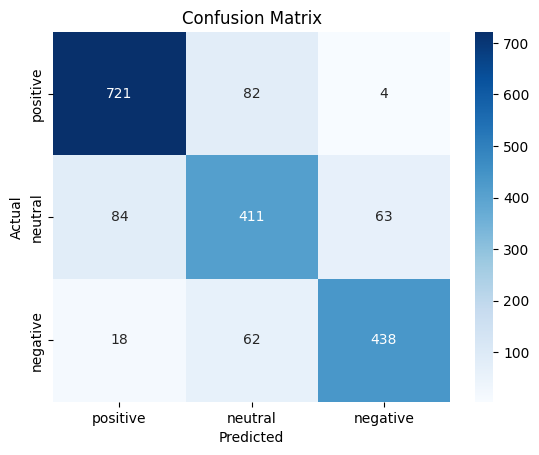

('./roberta-sentiment-model/tokenizer_config.json',
 './roberta-sentiment-model/special_tokens_map.json',
 './roberta-sentiment-model/vocab.json',
 './roberta-sentiment-model/merges.txt',
 './roberta-sentiment-model/added_tokens.json')

In [24]:
trainer.train()

_ = evaluate_model(trainer, test_dataset, list(test_labels))

model.save_pretrained("./roberta-sentiment-model")
tokenizer.save_pretrained("./roberta-sentiment-model")

# Task 2

## Clustering using Kmeans

In [ ]:
data = pd.concat([df2, df3], ignore_index=True)

In [ ]:
print("Shape:", data.shape)
print(data.columns)

Shape: (33332, 25)
Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateAdded',
       'reviews.dateSeen', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs',
       'reviews.didPurchase'],
      dtype='object')


In [ ]:
# Extract unique product names
unique_names = data[['name']].drop_duplicates().reset_index(drop=True)
print(f"Unique product names: {len(unique_names)}")
unique_names.head()


Unique product names: 79


,name
0,"Amazon Kindle E-Reader 6"" Wifi (8th Generation..."
1,Amazon Echo Show Alexa-enabled Bluetooth Speak...
2,Amazon Fire TV with 4K Ultra HD and Alexa Voic...
3,Amazon - Echo Plus w/ Built-In Hub - Silver
4,Amazon 9W PowerFast Official OEM USB Charger a...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorize the product names
vectorizer = TfidfVectorizer(stop_words='english')
name_vectors = vectorizer.fit_transform(unique_names['name'])

print("TF-IDF matrix shape:", name_vectors.shape)


TF-IDF matrix shape: (79, 222)


In [ ]:
from sklearn.cluster import KMeans

# Choose number of clusters (can change this)
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(name_vectors)

# Assign cluster labels
unique_names['cluster'] = kmeans.labels_


In [ ]:
# Display all names per cluster
for i in range(num_clusters):
    cluster_data = unique_names[unique_names['cluster'] == i]
    print(f"\nCluster {i} - Total products: {len(cluster_data)}")
    display(cluster_data)


Cluster 0 - Total products: 10


,name,cluster
23,AmazonBasics AAA Performance Alkaline Batterie...,0
24,AmazonBasics Nylon CD/DVD Binder (400 Capacity),0
29,AmazonBasics AA Performance Alkaline Batteries...,0
30,AmazonBasics Ventilated Adjustable Laptop Stand,0
32,AmazonBasics 11.6-Inch Laptop Sleeve,0
33,AmazonBasics 15.6-Inch Laptop and Tablet Bag,0
34,AmazonBasics External Hard Drive Case,0
38,AmazonBasics Silicone Hot Handle Cover/Holder ...,0
43,AmazonBasics USB 3.0 Cable - A-Male to B-Male ...,0
49,AmazonBasics Nespresso Pod Storage Drawer - 50...,0



Cluster 1 - Total products: 11


,name,cluster
6,"Kindle E-reader - White, 6 Glare-Free Touchscr...",1
13,Kindle Oasis E-reader with Leather Charging Co...,1
19,Kindle Oasis E-reader with Leather Charging Co...,1
42,"All-New Kindle E-reader - Black, 6"" Glare-Free...",1
48,"Kindle Voyage E-reader, 6 High-Resolution Disp...",1
56,Kindle Oasis E-reader with Leather Charging Co...,1
57,"Kindle Voyage E-reader, 6 High-Resolution Disp...",1
61,All-New Kindle Oasis E-reader - 7 High-Resolut...,1
70,Kindle Oasis E-reader with Leather Charging Co...,1
71,All-New Kindle Oasis E-reader - 7 High-Resolut...,1



Cluster 2 - Total products: 29


,name,cluster
0,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",2
1,Amazon Echo Show Alexa-enabled Bluetooth Speak...,2
2,Amazon Fire TV with 4K Ultra HD and Alexa Voic...,2
3,Amazon - Echo Plus w/ Built-In Hub - Silver,2
4,Amazon 9W PowerFast Official OEM USB Charger a...,2
11,Amazon Tap - Alexa-Enabled Portable Bluetooth ...,2
14,"Amazon - Kindle Voyage - 6"" - 4GB - Black",2
16,"Brand New Amazon Kindle Fire 16gb 7"" Ips Displ...",2
17,Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - Black,2
25,Amazon Echo ‚Äì White,2



Cluster 3 - Total products: 25


,name,cluster
5,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",3
7,"Fire Tablet, 7 Display, Wi-Fi, 16 GB - Include...",3
8,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",3
9,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",3
10,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",3
12,"Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 ...",3
15,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",3
18,"Fire HD 8 Tablet with Alexa, 8"" HD Display, 32...",3
20,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",3
21,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",3



Cluster 4 - Total products: 4


,name,cluster
31,AmazonBasics Backpack for Laptops up to 17-inches,4
44,Two Door Top Load Pet Kennel Travel Crate Dog ...,4
60,AmazonBasics Single-Door Folding Metal Dog Cra...,4
62,AmazonBasics Double-Door Folding Metal Dog Cra...,4


In [ ]:
# 4. Assign human-readable names to each cluster
cluster_name_map = {
    0: 'AmazonBasics Essentials',
    1: 'Kindle E-Readers',
    2: 'Alexa Devices & Accessories',
    3: 'Fire Tablets',
    4: 'Pet Supplies & Laptop Backpacks'
}
unique_names['category_group'] = unique_names['cluster'].map(cluster_name_map)

In [ ]:
# 5. Merge back with original data
data = data.merge(unique_names[['name', 'category_group']], on='name', how='left')

In [ ]:
data[['name', 'category_group']].drop_duplicates().sample(10)

,name,category_group
1633,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Fire Tablets
4687,Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - Black,Alexa Devices & Accessories
13352,Fire TV Stick Streaming Media Player Pair Kit,Alexa Devices & Accessories
18386,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Fire Tablets
17852,AmazonBasics USB 3.0 Cable - A-Male to B-Male ...,AmazonBasics Essentials
17863,AmazonBasics 16-Gauge Speaker Wire - 100 Feet,Alexa Devices & Accessories
17858,Two Door Top Load Pet Kennel Travel Crate Dog ...,Pet Supplies & Laptop Backpacks
18467,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Fire Tablets
4899,"Fire Tablet with Alexa, 7"" Display, 16 GB, Mag...",Fire Tablets
17835,"All-New Kindle E-reader - Black, 6"" Glare-Free...",Kindle E-Readers


# Task3

In [ ]:
from google.colab import userdata
api_key = userdata.get('key')

In [ ]:
import openai
from tqdm import tqdm
openai.api_key = api_key

In [ ]:
# extract top 3 and worst product per category
def get_top_and_worst_products(df, n_top=3):
    grouped = df.groupby('name')['reviews.rating'].agg(['mean', 'count']).reset_index()
    grouped = grouped[grouped['count'] >= 5]  # filter to avoid noise from too few reviews
    top_products = grouped.sort_values(by='mean', ascending=False).head(n_top)['name'].tolist()
    worst_product = grouped.sort_values(by='mean', ascending=True).head(1)['name'].values[0]
    return top_products, worst_product

In [ ]:
def get_top_complaints(df, product_name, n_complaints=3):
    product_reviews = df[df['name'] == product_name]
    low_rated_reviews = product_reviews[product_reviews['reviews.rating'] <= 2]
    top_complaints = low_rated_reviews.sort_values(by='reviews.rating').head(n_complaints)['reviews.text'].tolist()
    return top_complaints

In [ ]:
def generate_summary(category, top_products, complaints_dict, worst_product, worst_reason):
    messages = [
        {"role": "system", "content": "You are a helpful assistant who writes product review summaries like a blog post."},
        {"role": "user", "content": f"""
Write a short blog-style article for the category '{category}'.

1. Recommend the top 3 products: {top_products}.
2. Explain the key differences between them.
3. List the top complaints users had about each product: {complaints_dict}.
4. Also, mention the worst product in this category: '{worst_product}', and explain why users should avoid it based on complaints like: {worst_reason}.
"""}
    ]

    response = openai.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=messages,
        temperature=0.7
    )

    return response.choices[0].message.content

# Final summarization
summaries = {}

In [ ]:
for category in tqdm(data['category_group'].unique()):
    cluster_df = data[data['category_group'] == category]

    top_products, worst_product = get_top_and_worst_products(cluster_df)

    if len(top_products) < 3:
        continue  # Skip if too few products

    complaints_dict = {prod: get_top_complaints(cluster_df, prod) for prod in top_products}
    worst_reason = get_top_complaints(cluster_df, worst_product)

    summary = generate_summary(category, top_products, complaints_dict, worst_product, worst_reason)
    summaries[category] = summary

# Print results
for cat, summary in summaries.items():
    print(f"\n\n--- 🗂️ {cat} ---\n{summary}")

100%|██████████| 5/5 [00:19<00:00,  3.96s/it]



--- 🗂️ Alexa Devices & Accessories ---
If you're in the market for some new Alexa devices and accessories, look no further! We've rounded up the top 3 products that are sure to enhance your smart home experience. Let's dive in and explore the key features of each, along with some user feedback to help you make an informed decision.

1. **Certified Refurbished Amazon Echo**:
   - This smart speaker is a fan favorite for its voice-controlled capabilities and seamless integration with Alexa.
   - Key Differences: The Certified Refurbished version offers the same great features at a more affordable price point.
   - Top Complaints: Users have not reported significant complaints about this product.

2. **Fire TV Stick Streaming Media Player Pair Kit**:
   - With this pair kit, you can stream your favorite shows and movies in high definition on any TV.
   - Key Differences: The pair kit includes two Fire TV Stick devices, perfect for multiple TVs in your home.
   - Top Complaints: Users ha